In [2]:
from sklearn.datasets import make_blobs
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

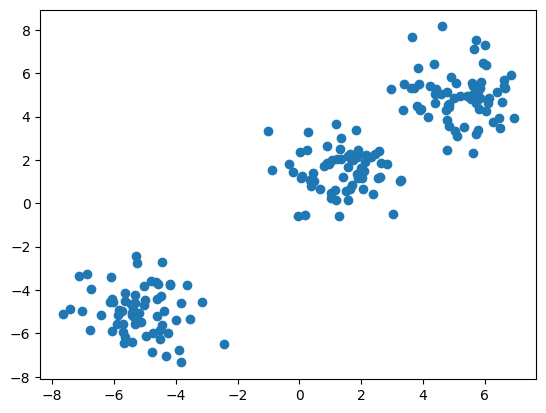

In [19]:
centroids = [(-5,-5),(1.5,1.5),(5,5)]
cluster_std = [1,1,1]

X,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=2,random_state=2)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [10]:
import random

In [14]:
#  kmeans class

class kmeans:
    def __init__(self,n_cluster,max_iteration):
        self.n_cluster = n_cluster 
        self.max_iteration = max_iteration
        self.centroids = None
        
    def fit_predict(self,X):
        idx = random.sample(range(0,X.shape[0]),self.n_cluster)
        self.centroids = X[idx]
        for i in range(self.max_iteration):
            # assign cluster
            cluster_group = self.assign_cluster(X)
            # move centroid
            old_centroid = self.centroids
            self.centroids = self.move_centroid(X,cluster_group)
            # check finish
            if(old_centroid==self.centroids).all():
                break
        return cluster_group
            
    def assign_cluster(self,X):
        cluster_group = []
        distance = []
        for row in X:
            for centroid in self.centroids:
                distance.append(np.sqrt(np.dot(row-centroid,row-centroid)))
                
            min_distance = min(distance)
            idx_pos = distance.index(min_distance)
            cluster_group.append(idx_pos)
            distance.clear()
                
        return np.array(cluster_group)
    
    def move_centroid(self,X,cluster_group):
        new_centroid = []
        cluster_type = np.unique(cluster_group)
        for type in cluster_type:
            new_centroid.append(X[cluster_group == type].mean(axis = 0))
        
        return np.array(new_centroid)
        

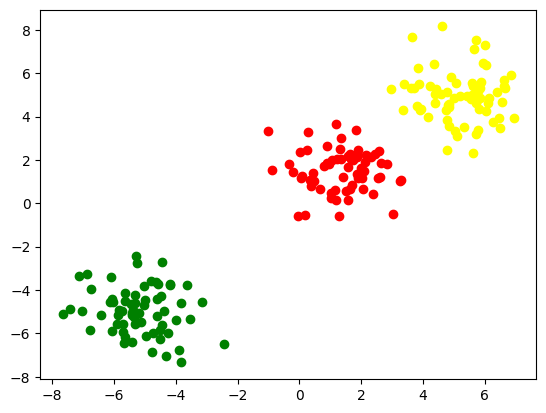

In [24]:
km = kmeans(n_cluster = 3,max_iteration =400)
y_pred = km.fit_predict(X)

plt.scatter(X[y_pred==0,0],X[y_pred==0,1],color = 'green')
plt.scatter(X[y_pred==1,0],X[y_pred==1,1],color= 'red')
plt.scatter(X[y_pred==2,0],X[y_pred==2,1],color= 'yellow')